In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Customer Churn Prediction Model/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## **6 Data Cleaning**

Remove Customer ID

In [6]:
df.drop("customerID",axis=1,inplace=True)

Convert TotalCharges

In [7]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

Fill Missing Values

In [8]:
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

/tmp/ipykernel_5533/1795292956.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


# **Step 7 Encode Data**

In [9]:
le=LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        df[col]=le.fit_transform(df[col])

# **Step 8 Split Data**

In [10]:
X=df.drop("Churn",axis=1)

y=df["Churn"]

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Step 9 Train Models**

Logistic Regression

In [12]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest

In [13]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

XGBoost

In [14]:
xgb=XGBClassifier()

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

# **Step 10 Compare Accuracy**

In [15]:
print("Logistic :",accuracy_score(y_test,pred_lr))

print("Random Forest :",accuracy_score(y_test,pred_rf))

print("XGBoost :",accuracy_score(y_test,pred_xgb))

Logistic : 0.8161816891412349
Random Forest : 0.7955997161107168
XGBoost : 0.7920511000709723


# **Step 11 Confusion Matrix**

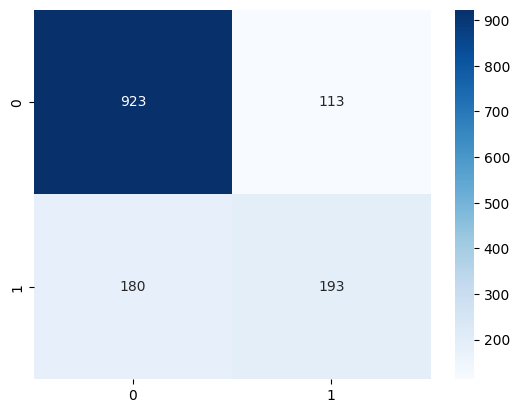

In [16]:
cm=confusion_matrix(y_test,pred_xgb)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.show()

# **Step 12 Classification Report**

In [17]:
print(classification_report(y_test,pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



# **Step 13 Feature Importance**

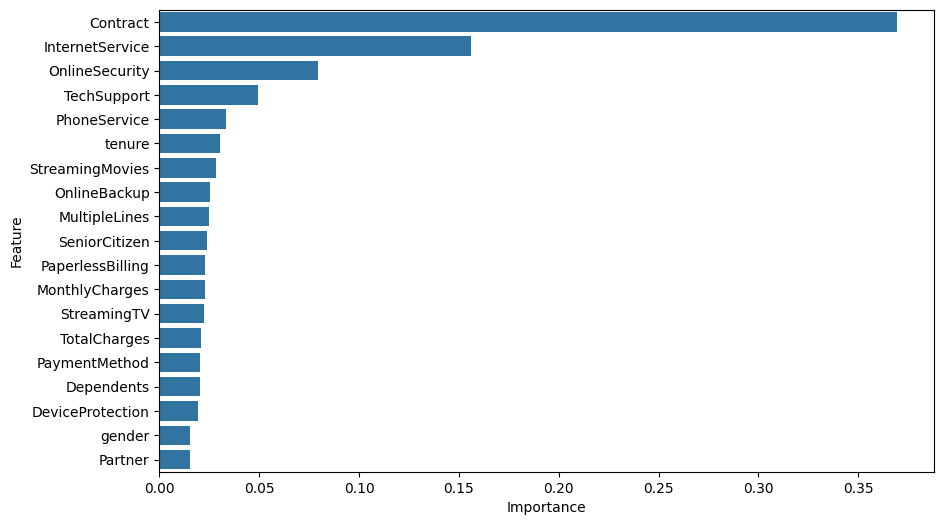

In [18]:
importance=xgb.feature_importances_

feature=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
})

feature=feature.sort_values("Importance",ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature,
    x="Importance",
    y="Feature"
)

plt.show()

# **Step 14 Churn Distribution**

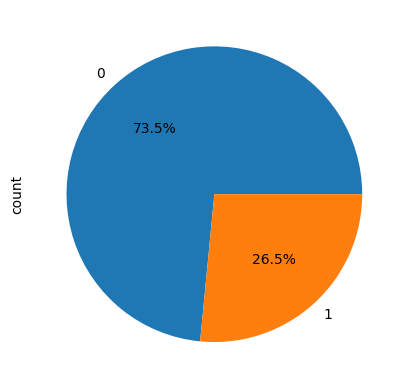

In [19]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

# **Step 15 Contract Type vs Churn**

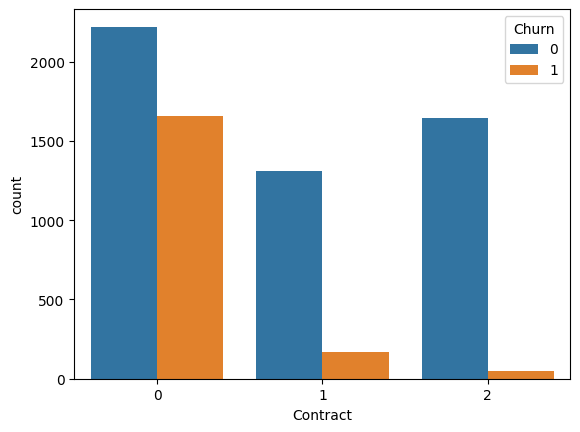

In [20]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.show()

# **Step 16 Monthly Charges**

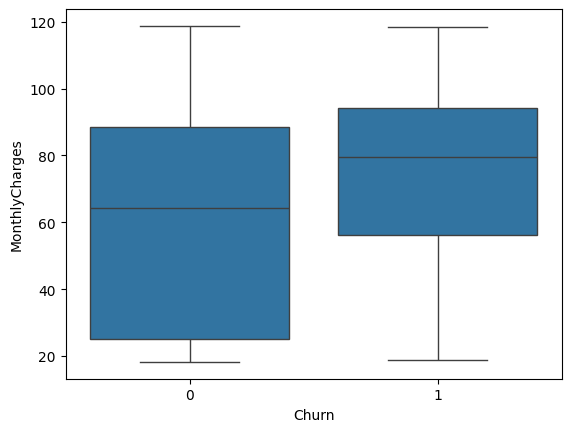

In [21]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

# **Step 17 Save Model**

In [22]:
joblib.dump(xgb,"churn_model.pkl")

['churn_model.pkl']

# **Step 18 Predict New Customer**

In [23]:
model=joblib.load("churn_model.pkl")

sample=X.iloc[[0]]

prediction=model.predict(sample)

print(prediction)

[1]


# **Step 19 Export Clean Data**

In [24]:
df.to_csv("cleaned_data.csv",index=False)